# Water-Cooled Finned Chip: Conjugate Heat Transfer Notebook

This is executable notebook source in **Jupytext percent format**. Rename this
text file to `.py`, then convert it with:

```bash
pip install jupytext numpy pandas matplotlib
jupytext --to notebook chip_cooling_notebook.py
```

Alternatively, copy each `# %% [markdown]` block into a Markdown cell and each
`# %%` block into a Code cell.

The model includes governing equations, finite-volume discretization, a
reduced conjugate heat-transfer calculation, pressure drop, temperature and
velocity fields, grid convergence, sensitivity studies, and balance checks.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
pd.set_option("display.precision", 6)

"""!!!!!In Terminal > jupytext --to notebook chip_cooling_conjugate_heat_transfer_notebook.py
Show more lines !!!!!!!"""

'!!!!!In Terminal > jupytext --to notebook chip_cooling_conjugate_heat_transfer_notebook.py\nShow more lines !!!!!!!'

## 1. Inputs and assumptions

Chip size:

$$L\times W=10\ \mathrm{mm}\times10\ \mathrm{mm}$$

Fin and channel geometry:

$$t=1\ \mathrm{mm},\quad s=1\ \mathrm{mm},\quad H=10\ \mathrm{mm}$$

Operating point:

$$\dot V=0.1\ \mathrm{L/min},\quad T_{b,\max}=60^\circ\mathrm C$$

The water inlet temperature was not specified, so the baseline assumes
$T_{in}=25^\circ\mathrm C$. Water properties are treated as constant and the
fins are aluminum. Five fins and five channels are used as a periodic
interpretation of the 10 mm width. Modify the inputs if the actual edge-wall
arrangement is different.

In [2]:
# Geometry [m]
L, W = 10e-3, 10e-3
H, t_fin, s = 10e-3, 1e-3, 1e-3
N_fins, N_channels = 5, 5

# Operating conditions
flow_LPM = 0.1
T_in = 25.0
T_base = 60.0

# Water properties near 35-40 degC
rho = 992.2       # kg/m3
mu = 6.53e-4      # Pa s
cp = 4179.0       # J/(kg K)
k_water = 0.63    # W/(m K)

# Aluminum
k_solid = 200.0   # W/(m K)

# Preliminary average Nusselt number, user-adjustable
Nu = 4.0

# Numerical controls
N_cells = 50

## 2. Governing equations

### 2.1 Continuity

General conservation of mass:

$$\frac{\partial\rho}{\partial t}+\nabla\cdot(\rho\mathbf u)=0$$

For steady incompressible water:

$$\boxed{\nabla\cdot\mathbf u=0}$$

or

$$\boxed{\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}+\frac{\partial w}{\partial z}=0}$$

### 2.2 Momentum

For an incompressible Newtonian fluid:

$$\rho\left(\frac{\partial\mathbf u}{\partial t}+\mathbf u\cdot\nabla\mathbf u\right)
=-\nabla p+\mu\nabla^2\mathbf u+\rho\mathbf g$$

For steady forced flow with negligible buoyancy:

$$\boxed{\rho(\mathbf u\cdot\nabla)\mathbf u=-\nabla p+\mu\nabla^2\mathbf u}$$

### 2.3 Fluid energy

Neglecting viscous dissipation, pressure work, and fluid heat generation:

$$\rho c_p\left(\frac{\partial T_f}{\partial t}+\mathbf u\cdot\nabla T_f\right)
=\nabla\cdot(k_f\nabla T_f)$$

At steady state with constant properties:

$$\boxed{\rho c_p\mathbf u\cdot\nabla T_f=k_f\nabla^2T_f}$$

### 2.4 Solid energy

$$\rho_sc_{p,s}\frac{\partial T_s}{\partial t}
=\nabla\cdot(k_s\nabla T_s)+\dot q_s'''$$

At steady state:

$$\boxed{\nabla\cdot(k_s\nabla T_s)+\dot q_s'''=0}$$

Without heat generation in the aluminum:

$$\boxed{\nabla^2T_s=0}$$

### 2.5 Fluid-solid interface

$$\boxed{T_f=T_s=T_i}$$

$$\boxed{-k_f\frac{\partial T_f}{\partial n}=-k_s\frac{\partial T_s}{\partial n}}$$

## 3. Boundary conditions for a full CHT model

Water inlet:

$$\dot V=0.1\ \mathrm{L/min},\qquad T_f=T_{in}$$

Pressure outlet:

$$p=p_{out},\qquad \frac{\partial T_f}{\partial x}=0$$

Wetted walls:

$$u=v=w=0$$

Chip heat input:

$$q_{chip}''=\frac{Q_{chip}}{A_{chip}}$$

The allowable power satisfies:

$$\boxed{\max(T_{base})=60^\circ\mathrm C}$$

Initially, non-wetted surfaces may be treated as adiabatic:

$$-k_s\nabla T_s\cdot\mathbf n=0$$

## 4. Finite-volume discretization

For cell $P$, integration of continuity gives:

$$\int_{V_P}\nabla\cdot(\rho\mathbf u)dV=0$$

Using the divergence theorem:

$$\boxed{\sum_f\dot m_f=0},\qquad
\dot m_f=\rho_f\mathbf u_f\cdot\mathbf S_f$$

In Cartesian form:

$$\dot m_e-\dot m_w+\dot m_n-\dot m_s+\dot m_t-\dot m_b=0$$

Momentum and energy use the generic convection-diffusion equation:

$$\nabla\cdot(\rho\mathbf u\phi)=\nabla\cdot(\Gamma_\phi\nabla\phi)+S_\phi$$

Integrating over a cell gives:

$$\sum_f\rho_f\phi_f\mathbf u_f\cdot\mathbf S_f
=\sum_f\Gamma_{\phi,f}(\nabla\phi)_f\cdot\mathbf S_f+S_{\phi,P}V_P$$

which is rearranged as:

$$\boxed{a_P\phi_P=\sum_{nb}a_{nb}\phi_{nb}+b_P}$$

At the east face:

$$D_e=\frac{\Gamma_eA_e}{\delta_{PE}},\qquad F_e=\dot m_e$$

First-order upwind interpolation is:

$$\phi_e=\begin{cases}\phi_P,&F_e>0\\\phi_E,&F_e<0\end{cases}$$

Typical coefficients are:

$$a_E=D_e+\max(-F_e,0),\qquad a_W=D_w+\max(F_w,0)$$

For $x$ momentum:

$$a_P^uu_P=\sum_{nb}a_{nb}^uu_{nb}+(p_W-p_E)A_x+b_u$$

For fluid temperature, with $F_f^T=\dot m_fc_p$ and
$D_f^T=k_fA_f/\delta_f$:

$$\boxed{a_P^TT_{f,P}=\sum_{nb}a_{nb}^TT_{f,nb}+b_T}$$

For a solid cell:

$$\boxed{a_P^sT_{s,P}=\sum_{nb}a_{nb}^sT_{s,nb}+b_s}$$

$$a_{nb}^s=\frac{k_{s,f}A_f}{\delta_{P,nb}},\qquad
b_s=\dot q'''V_P$$

At a fluid-solid face shared by cells $F$ and $S$:

$$\boxed{G_i=\frac{A_i}{\delta_s/k_s+\delta_f/k_f}}$$

$$\boxed{q_i=G_i(T_S-T_F)}$$

With area-specific contact resistance $R_c''$:

$$G_i=\frac{A_i}{\delta_s/k_s+R_c''+\delta_f/k_f}$$

## 5. Pressure-velocity coupling

In a SIMPLE-type method:

$$p=p^*+p',\qquad \mathbf u=\mathbf u^*+\mathbf u'$$

A face-velocity correction is written:

$$u_f'=d_f(p_P'-p_{nb}')$$

Substitution into continuity gives the pressure-correction equation:

$$\boxed{a_P^{p'}p_P'=\sum_{nb}a_{nb}^{p'}p_{nb}'-\sum_f\dot m_f^*}$$

Correct the fields using:

$$p^{new}=p^*+\alpha_pp',\qquad \mathbf u^{new}=\mathbf u^*+\mathbf u'$$

Solver loop:

```text
initialize p, u, v, w, Tf, Ts
while not converged:
    solve momentum equations
    solve pressure-correction equation
    correct pressure, velocity, and mass fluxes
    solve fluid energy
    solve solid energy
    exchange interface temperature and heat flux
    check residuals and global balances
```

## 6. Geometry, flow rate, and dimensionless groups

$$\dot V_{SI}=\dot V_{LPM}\frac{10^{-3}}{60},\qquad \dot m=\rho\dot V$$

$$A_{ch}=sH,\qquad A_{flow}=N_cA_{ch},\qquad \bar V=\frac{\dot V}{A_{flow}}$$

$$D_h=\frac{2sH}{s+H}$$

$$Re=\frac{\rho\bar VD_h}{\mu},\qquad Pr=\frac{\mu c_p}{k_f}$$

In [3]:
flow_m3_s = flow_LPM * 1e-3 / 60.0
m_dot = rho * flow_m3_s
A_chip = L * W
pitch = t_fin + s
A_channel = s * H
A_flow = N_channels * A_channel
V_mean = flow_m3_s / A_flow
D_h = 2 * s * H / (s + H)
Re = rho * V_mean * D_h / mu
Pr = mu * cp / k_water

pd.Series({
    "Pitch [m]": pitch,
    "Nominal pitches across width": W / pitch,
    "Flow rate [m3/s]": flow_m3_s,
    "Mass flow [kg/s]": m_dot,
    "Total flow area [m2]": A_flow,
    "Mean velocity [m/s]": V_mean,
    "Hydraulic diameter [m]": D_h,
    "Reynolds number": Re,
    "Prandtl number": Pr,
})

Pitch [m]                        0.002000
Nominal pitches across width     5.000000
Flow rate [m3/s]                 0.000002
Mass flow [kg/s]                 0.001654
Total flow area [m2]             0.000050
Mean velocity [m/s]              0.033333
Hydraulic diameter [m]           0.001818
Reynolds number                 92.087800
Prandtl number                   4.331567
dtype: float64

## 7. Entrance lengths

Approximate laminar entrance lengths are:

$$L_h\approx0.05ReD_h$$

$$L_t\approx0.05RePrD_h$$

Values comparable to the 10 mm channel length show that developing-flow
effects are important.

In [4]:
L_h = 0.05 * Re * D_h
L_t = 0.05 * Re * Pr * D_h
pd.Series({"L_h [m]": L_h, "L_t [m]": L_t, "L_h/L": L_h/L, "L_t/L": L_t/L})

L_h [m]    0.008372
L_t [m]    0.036262
L_h/L      0.837162
L_t/L      3.626222
dtype: float64

## 8. Heat-transfer coefficient and fin efficiency

$$\boxed{h=\frac{Nu\,k_f}{D_h}}$$

For a thin rectangular fin:

$$m\approx\sqrt{\frac{2h}{k_st}},\qquad L_c=H+\frac{t}{2}$$

$$\boxed{\eta_f=\frac{\tanh(mL_c)}{mL_c}}$$

$$A_{fin}=N_f(2L_cL),\qquad A_b=N_csL$$

$$\boxed{A_{eff}=A_b+\eta_fA_{fin}}$$

In [5]:
h = Nu * k_water / D_h
L_c = H + t_fin/2
m_fin = math.sqrt(2*h/(k_solid*t_fin))
eta_fin = math.tanh(m_fin*L_c)/(m_fin*L_c)
A_fin = N_fins * 2 * L_c * L
A_base = N_channels * s * L
A_eff = A_base + eta_fin*A_fin
UA = h*A_eff

pd.Series({
    "h [W/(m2 K)]": h,
    "m [1/m]": m_fin,
    "mLc": m_fin*L_c,
    "Fin efficiency": eta_fin,
    "Fin area [m2]": A_fin,
    "Exposed base area [m2]": A_base,
    "Effective area [m2]": A_eff,
    "UA [W/K]": UA,
})

h [W/(m2 K)]              1386.000000
m [1/m]                    117.728501
mLc                          1.236149
Fin efficiency               0.683052
Fin area [m2]                0.001050
Exposed base area [m2]       0.000050
Effective area [m2]          0.000767
UA [W/K]                     1.063345
dtype: float64

## 9. Coupled heat-removal estimate

Water heat-capacity rate:

$$C=\dot mc_p$$

Number of transfer units:

$$NTU=\frac{UA}{C}$$

The bulk-temperature equation for an approximately constant base temperature is:

$$C\frac{dT_m}{dx}=\frac{UA}{L}(T_b-T_m)$$

Its solution is:

$$\boxed{T_m(x)=T_b-(T_b-T_{in})\exp\left(-NTU\frac{x}{L}\right)}$$

Therefore:

$$\boxed{T_{out}=T_b-(T_b-T_{in})e^{-NTU}}$$

$$\boxed{Q=C(T_b-T_{in})(1-e^{-NTU})}$$

In [6]:
C = m_dot*cp
NTU = UA/C
T_out = T_base - (T_base-T_in)*math.exp(-NTU)
Q_max = C*(T_out-T_in)
q_chip = Q_max/A_chip
R_total = (T_base-T_in)/Q_max

pd.Series({
    "Water capacity rate [W/K]": C,
    "NTU": NTU,
    "Outlet temperature [degC]": T_out,
    "Estimated allowable power [W]": Q_max,
    "Chip heat flux [W/m2]": q_chip,
    "Chip heat flux [W/cm2]": q_chip/1e4,
    "Base-to-inlet thermal resistance [K/W]": R_total,
})

Water capacity rate [W/K]                      6.910673
NTU                                            0.153870
Outlet temperature [degC]                     29.991577
Estimated allowable power [W]                 34.495160
Chip heat flux [W/m2]                     344951.595826
Chip heat flux [W/cm2]                        34.495160
Base-to-inlet thermal resistance [K/W]         1.014635
dtype: float64

## 10. Pressure drop

For aspect ratio $\alpha=s/H$:

$$f_DRe=96(1-1.3553\alpha+1.9467\alpha^2-1.7012\alpha^3
+0.9564\alpha^4-0.2537\alpha^5)$$

$$f_D=\frac{f_DRe}{Re}$$

$$\boxed{\Delta p=f_D\frac{L}{D_h}\frac{\rho\bar V^2}{2}}$$

This is only the ideal straight-channel core loss.

In [7]:
alpha = min(s,H)/max(s,H)
fRe = 96*(1-1.3553*alpha+1.9467*alpha**2-1.7012*alpha**3+0.9564*alpha**4-0.2537*alpha**5)
f_D = fRe/Re
delta_p = f_D*(L/D_h)*rho*V_mean**2/2
pd.Series({"Aspect ratio": alpha, "fRe": fRe, "Darcy f": f_D, "Pressure drop [Pa]": delta_p})

Aspect ratio           0.100000
fRe                   84.703575
Darcy f                0.919813
Pressure drop [Pa]     2.788618
dtype: float64

## 11. Approximate velocity field

Approximating the narrow channel as two parallel plates:

$$\boxed{u(y)=6\bar V\frac{y}{s}\left(1-\frac{y}{s}\right)}$$

Hence:

$$u(0)=u(s)=0,\qquad u_{max}=1.5\bar V$$

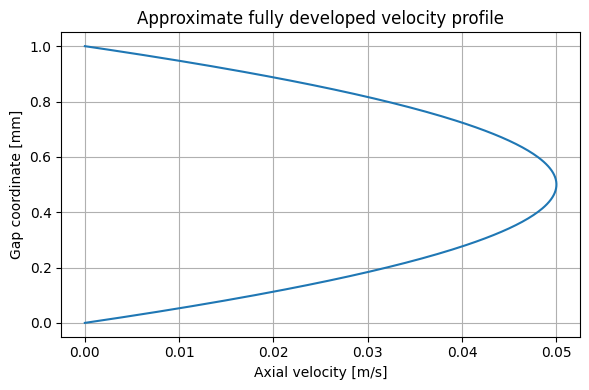

Mean velocity [m/s] = 0.03333333333333333
Maximum approximate velocity [m/s] = 0.04999919356139418


In [8]:
y = np.linspace(0,s,250)
u = 6*V_mean*(y/s)*(1-y/s)
plt.figure(figsize=(6,4))
plt.plot(u,y*1e3)
plt.xlabel("Axial velocity [m/s]")
plt.ylabel("Gap coordinate [mm]")
plt.title("Approximate fully developed velocity profile")
plt.grid(True)
plt.tight_layout()
plt.show()
print("Mean velocity [m/s] =", V_mean)
print("Maximum approximate velocity [m/s] =", u.max())

## 12. Analytical bulk-temperature field

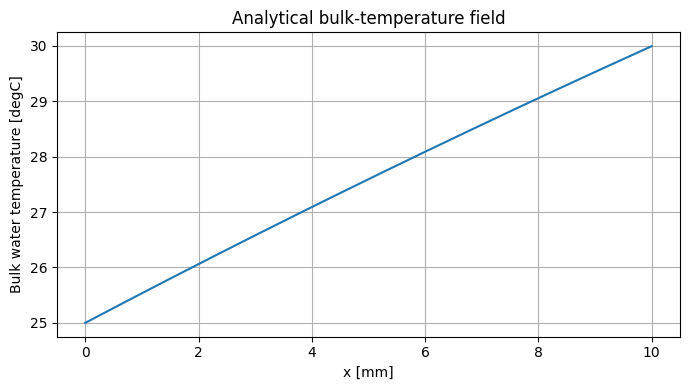

,x [mm],T_bulk [degC]
0,0.0,25.000000
1,2.5,26.320796
2,5.0,27.591748
3,7.5,28.814739
4,10.0,29.991577


In [9]:
x = np.linspace(0,L,250)
T_analytical = T_base-(T_base-T_in)*np.exp(-NTU*x/L)
plt.figure(figsize=(7,4))
plt.plot(x*1e3,T_analytical)
plt.xlabel("x [mm]")
plt.ylabel("Bulk water temperature [degC]")
plt.title("Analytical bulk-temperature field")
plt.grid(True)
plt.tight_layout()
plt.show()

sample_x = np.linspace(0,L,5)
sample_T = T_base-(T_base-T_in)*np.exp(-NTU*sample_x/L)
pd.DataFrame({"x [mm]":sample_x*1e3,"T_bulk [degC]":sample_T})

## 13. One-dimensional finite-volume energy solver

Let $U'=UA/L$ and divide the channel into cells of length $\Delta x=L/N$.
Integrating the bulk energy equation over cell $i$ with positive flow and
first-order upwind convection gives:

$$C(T_i-T_{i-1})=U'\Delta x(T_b-T_i)$$

Thus:

$$\boxed{(C+U'\Delta x)T_i=CT_{i-1}+U'\Delta xT_b}$$

The following function assembles and solves the lower-bidiagonal system.

Maximum cell-center error [K] = 0.0535654538454402


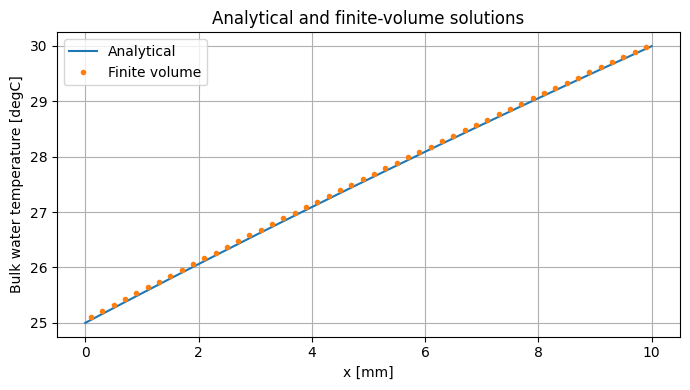

In [10]:
def solve_1d_fvm(N,L,C,UA,Tin,Tb):
    dx=L/N
    Up=UA/L
    A=np.zeros((N,N))
    b=np.zeros(N)
    for i in range(N):
        A[i,i]=C+Up*dx
        b[i]=Up*dx*Tb
        if i==0:
            b[i]+=C*Tin
        else:
            A[i,i-1]=-C
    T=np.linalg.solve(A,b)
    xc=(np.arange(N)+0.5)*dx
    return xc,T,A,b

xc,T_fvm,A_matrix,b_vector=solve_1d_fvm(N_cells,L,C,UA,T_in,T_base)
T_exact_cells=T_base-(T_base-T_in)*np.exp(-NTU*xc/L)
error=np.max(np.abs(T_fvm-T_exact_cells))
print("Maximum cell-center error [K] =",error)

plt.figure(figsize=(7,4))
plt.plot(x*1e3,T_analytical,label="Analytical")
plt.plot(xc*1e3,T_fvm,"o",ms=3,label="Finite volume")
plt.xlabel("x [mm]")
plt.ylabel("Bulk water temperature [degC]")
plt.title("Analytical and finite-volume solutions")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 14. Grid-convergence study

,Cells,dx [mm],Max error [K],Last-cell T [degC]
0,5,2.0000,0.510510,29.921874
1,10,1.0000,0.262145,29.956393
2,20,0.5000,0.132839,29.973901
3,40,0.2500,0.066867,29.982718
4,80,0.1250,0.033546,29.987142
5,160,0.0625,0.016801,29.989359


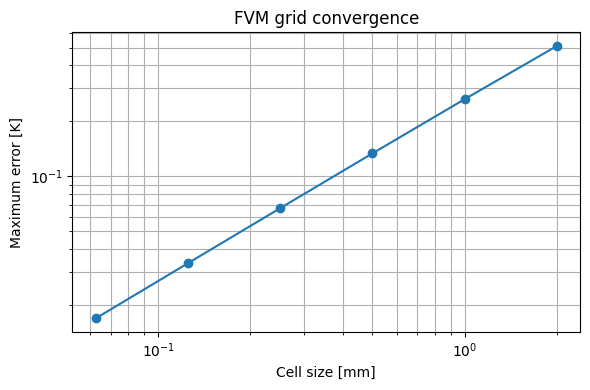

In [11]:
records=[]
for N in [5,10,20,40,80,160]:
    xN,TN,_,_=solve_1d_fvm(N,L,C,UA,T_in,T_base)
    Te=T_base-(T_base-T_in)*np.exp(-NTU*xN/L)
    records.append([N,L/N*1e3,np.max(np.abs(TN-Te)),TN[-1]])
grid_df=pd.DataFrame(records,columns=["Cells","dx [mm]","Max error [K]","Last-cell T [degC]"])
display(grid_df)
plt.figure(figsize=(6,4))
plt.loglog(grid_df["dx [mm]"],grid_df["Max error [K]"],"o-")
plt.xlabel("Cell size [mm]")
plt.ylabel("Maximum error [K]")
plt.title("FVM grid convergence")
plt.grid(True,which="both")
plt.tight_layout()
plt.show()

## 15. Approximate fin temperature profile

For a straight fin with an adiabatic-tip approximation:

$$\frac{\theta(y)}{\theta_b}=\frac{\cosh[m(L_c-y)]}{\cosh(mL_c)}$$

where $\theta=T-T_\infty$. The plot uses the bulk water temperature at the
channel midpoint as $T_\infty$.

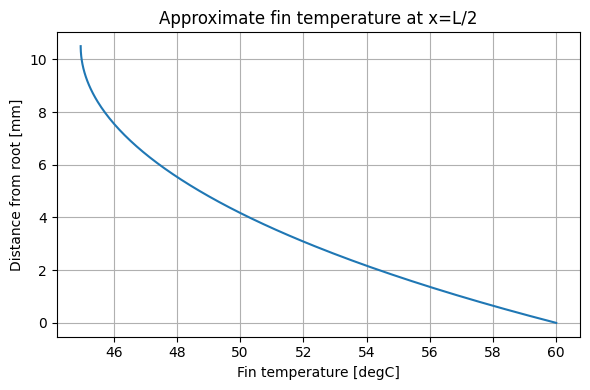

In [12]:
T_bulk_mid=T_base-(T_base-T_in)*math.exp(-NTU*0.5)
yf=np.linspace(0,L_c,200)
theta_ratio=np.cosh(m_fin*(L_c-yf))/np.cosh(m_fin*L_c)
Tfin=T_bulk_mid+(T_base-T_bulk_mid)*theta_ratio
plt.figure(figsize=(6,4))
plt.plot(Tfin,yf*1e3)
plt.xlabel("Fin temperature [degC]")
plt.ylabel("Distance from root [mm]")
plt.title("Approximate fin temperature at x=L/2")
plt.grid(True)
plt.tight_layout()
plt.show()

## 16. Energy-balance check

$$Q_{water}=\dot mc_p(T_{out}-T_{in})$$

$$Q_{surface}=C(T_b-T_{in})(1-e^{-NTU})$$

$$\epsilon_Q=\frac{|Q_{water}-Q_{surface}|}{Q_{surface}}$$

In [13]:
Q_water=m_dot*cp*(T_out-T_in)
Q_surface=C*(T_base-T_in)*(1-math.exp(-NTU))
imbalance=abs(Q_water-Q_surface)/Q_surface
pd.Series({"Q_water [W]":Q_water,"Q_surface [W]":Q_surface,"Relative imbalance":imbalance})

Q_water [W]           3.449516e+01
Q_surface [W]         3.449516e+01
Relative imbalance    2.059833e-16
dtype: float64

## 17. Sensitivity to inlet temperature

$$Q(T_{in})=C(T_b-T_{in})(1-e^{-NTU})$$

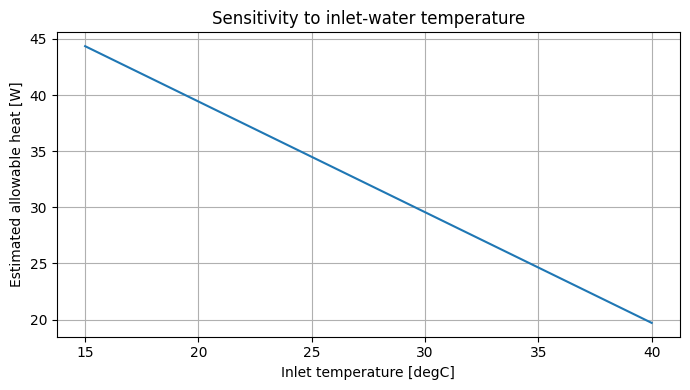

In [14]:
Tin_values=np.linspace(15,40,101)
Q_Tin=C*(T_base-Tin_values)*(1-np.exp(-NTU))
plt.figure(figsize=(7,4))
plt.plot(Tin_values,Q_Tin)
plt.xlabel("Inlet temperature [degC]")
plt.ylabel("Estimated allowable heat [W]")
plt.title("Sensitivity to inlet-water temperature")
plt.grid(True)
plt.tight_layout()
plt.show()

## 18. Sensitivity to assumed Nusselt number

This recalculates $h$, fin efficiency, effective area, $UA$, outlet
temperature, and allowable heat for each $Nu$.

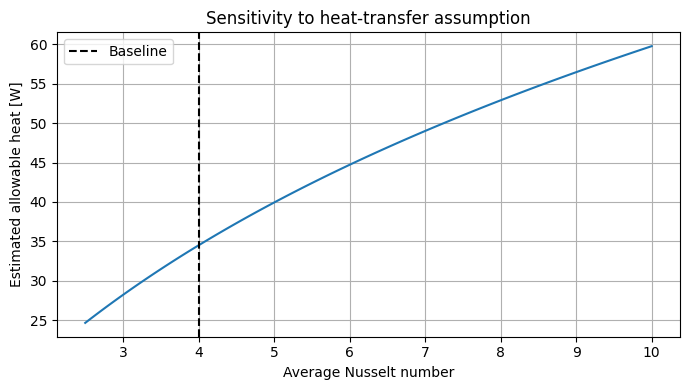

,Nu,h,eta,UA,NTU,Q [W],Tout [degC]
0,2.500000,866.25,0.769372,0.743105,0.107530,24.659110,28.568265
20,4.015152,1391.25,0.682303,1.066279,0.154294,34.583179,30.004314
40,5.530303,1916.25,0.616706,1.336664,0.193420,42.536946,31.155254
60,7.045455,2441.25,0.565383,1.571317,0.227375,49.191837,32.118241
80,8.560606,2966.25,0.524039,1.780463,0.257640,54.935849,32.949421
99,10.000000,3465.00,0.491511,1.961490,0.283835,59.769135,33.648815


In [15]:
def performance_from_Nu(Nu_i):
    hi=Nu_i*k_water/D_h
    mi=math.sqrt(2*hi/(k_solid*t_fin))
    etai=math.tanh(mi*L_c)/(mi*L_c)
    Aeffi=A_base+etai*A_fin
    UAi=hi*Aeffi
    NTUi=UAi/C
    Qi=C*(T_base-T_in)*(1-math.exp(-NTUi))
    Touti=T_in+Qi/C
    return hi,etai,UAi,NTUi,Qi,Touti

Nu_values=np.linspace(2.5,10,100)
Nu_data=[]
for value in Nu_values:
    Nu_data.append((value,*performance_from_Nu(value)))
Nu_df=pd.DataFrame(Nu_data,columns=["Nu","h","eta","UA","NTU","Q [W]","Tout [degC]"])
plt.figure(figsize=(7,4))
plt.plot(Nu_df["Nu"],Nu_df["Q [W]"])
plt.axvline(Nu,color="black",linestyle="--",label="Baseline")
plt.xlabel("Average Nusselt number")
plt.ylabel("Estimated allowable heat [W]")
plt.title("Sensitivity to heat-transfer assumption")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
display(Nu_df.iloc[[0,20,40,60,80,99]])

## 19. Sensitivity to flow rate

This simple sweep holds $Nu$ fixed, so it isolates the water heat-capacity
effect. A higher-fidelity sweep should update a developing-flow correlation
$Nu(Re,Pr,L/D_h,\alpha)$ at every flow rate.

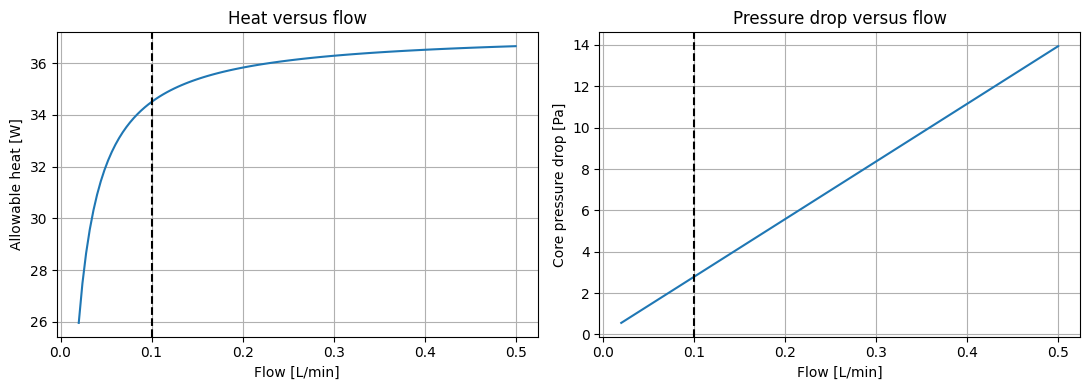

In [16]:
def performance_from_flow(flow_i_LPM):
    Vdot=flow_i_LPM*1e-3/60
    mdot=rho*Vdot
    velocity=Vdot/A_flow
    Rei=rho*velocity*D_h/mu
    Ci=mdot*cp
    NTUi=UA/Ci
    Qi=Ci*(T_base-T_in)*(1-math.exp(-NTUi))
    Touti=T_in+Qi/Ci
    fi=fRe/Rei
    dpi=fi*(L/D_h)*rho*velocity**2/2
    return Rei,Qi,Touti,dpi

flows=np.linspace(0.02,0.5,120)
flow_data=[]
for value in flows:
    flow_data.append((value,*performance_from_flow(value)))
flow_df=pd.DataFrame(flow_data,columns=["Flow [LPM]","Re","Q [W]","Tout [degC]","Delta p [Pa]"])
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(flow_df["Flow [LPM]"],flow_df["Q [W]"])
ax[0].axvline(flow_LPM,color="black",linestyle="--")
ax[0].set(xlabel="Flow [L/min]",ylabel="Allowable heat [W]",title="Heat versus flow")
ax[0].grid(True)
ax[1].plot(flow_df["Flow [LPM]"],flow_df["Delta p [Pa]"])
ax[1].axvline(flow_LPM,color="black",linestyle="--")
ax[1].set(xlabel="Flow [L/min]",ylabel="Core pressure drop [Pa]",title="Pressure drop versus flow")
ax[1].grid(True)
plt.tight_layout()
plt.show()

## 20. Final summary

Under the baseline assumptions, expected values are approximately:

$$Re\approx92$$

$$h\approx1.39\times10^3\ \mathrm{W/(m^2K)}$$

$$\eta_f\approx0.68$$

$$Q_{max}\approx34.5\ \mathrm W$$

$$T_{out}\approx30.0^\circ\mathrm C$$

$$\Delta p_{straight\ channels}\approx2.8\ \mathrm{Pa}$$

In [17]:
summary=pd.DataFrame({
    "Quantity":["Flow","Mass flow","Mean velocity","Hydraulic diameter","Re","Pr","Nu","h","Fin efficiency","Effective area","UA","Outlet temperature","Allowable power","Heat flux","Thermal resistance","Core pressure drop"],
    "Value":[flow_LPM,m_dot,V_mean,D_h,Re,Pr,Nu,h,eta_fin,A_eff,UA,T_out,Q_max,q_chip/1e4,R_total,delta_p],
    "Unit":["L/min","kg/s","m/s","m","-","-","-","W/(m2 K)","-","m2","W/K","degC","W","W/cm2","K/W","Pa"]
})
display(summary)

,Quantity,Value,Unit
0,Flow,0.100000,L/min
1,Mass flow,0.001654,kg/s
2,Mean velocity,0.033333,m/s
3,Hydraulic diameter,0.001818,m
4,Re,92.087800,-
5,Pr,4.331567,-
6,Nu,4.000000,-
7,h,1386.000000,W/(m2 K)
8,Fin efficiency,0.683052,-
9,Effective area,0.000767,m2


## 21. Limitations and next steps

This is a preliminary reduced-order result. Important uncertainties include:

1. unspecified inlet and outlet manifolds;
2. possible channel flow maldistribution;
3. thermal and hydrodynamic development;
4. the assumed average Nusselt number;
5. neglected chip-to-base contact resistance;
6. neglected base spreading resistance;
7. constant water properties;
8. ideal geometry, no roughness or fouling;
9. pressure losses outside the straight channels.

A full CFD verification should include the solid and fluid domains, headers,
coupled interfaces, wall refinement, and a chip-power iteration until:

$$\max(T_{base})=60^\circ\mathrm C$$

Convergence should be checked using mass and energy balances:

$$|\dot m_{in}-\dot m_{out}|\ll\dot m_{in}$$

$$\frac{|Q_{chip}-\dot mc_p(T_{out}-T_{in})|}{Q_{chip}}\ll1$$

Perform at least three mesh levels and compare maximum base temperature,
outlet temperature, pressure drop, and total wall heat transfer.